# L1 & L2 Regression on Position vs Salary Dataset
This notebook applies Ridge (L2) and Lasso (L1) Regression to predict Salary from Position Level.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


            Position  Level  Salary
0   Business Analyst      1   45000
1  Junior Consultant      2   50000
2  Senior Consultant      3   60000
3            Manager      4   80000
4    Country Manager      5  110000
📘 Ridge (L2) Regression Results
R² Score: 0.8616
Mean Squared Error (MSE): 7005857355.1063
Mean Absolute Error (MAE): 77394.0678
--------------------------------------------------
📘 Lasso (L1) Regression Results
R² Score: 0.8451
Mean Squared Error (MSE): 7840049433.4149
Mean Absolute Error (MAE): 82607.7103
--------------------------------------------------
✅ Ridge Regression Accuracy (R²): 0.8616
✅ Lasso Regression Accuracy (R²): 0.8451


/tmp/ipython-input-4190281687.py:52: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  X_grid = np.arange(min(X), max(X), 0.1).reshape(-1, 1)


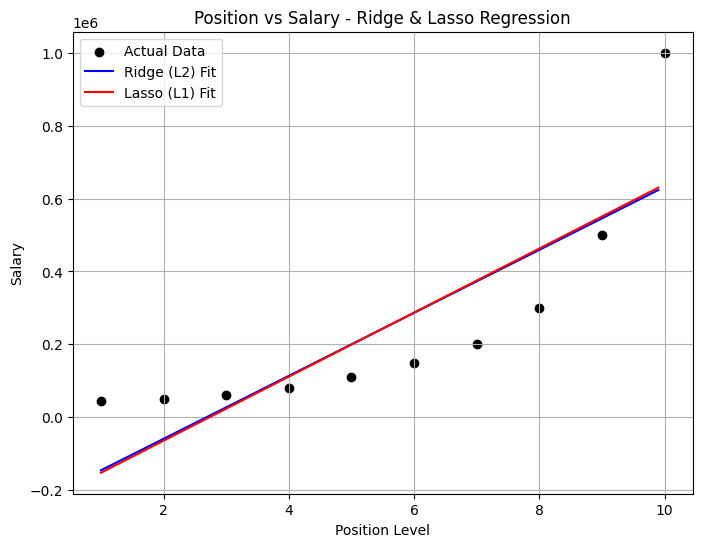

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge, Lasso
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# --- Load dataset (Position vs Salary) ---
df = pd.read_csv('/content/drive/MyDrive/ML/Regression/dataset/Position_Salaries.csv')
print(df.head())

# --- Define features and target ---
X = df[['Level']].values
y = df['Salary'].values

# --- Train/test split ---
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# --- Ridge Regression (L2) ---
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train, y_train)
ridge_pred = ridge_model.predict(X_test)

# --- Lasso Regression (L1) ---
lasso_model = Lasso(alpha=0.1)
lasso_model.fit(X_train, y_train)
lasso_pred = lasso_model.predict(X_test)

# --- Evaluation Function ---
def evaluate_model(name, y_true, y_pred):
    r2 = r2_score(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    print(f'📘 {name} Regression Results')
    print(f'R² Score: {r2:.4f}')
    print(f'Mean Squared Error (MSE): {mse:.4f}')
    print(f'Mean Absolute Error (MAE): {mae:.4f}')
    print('-'*50)
    return r2

ridge_r2 = evaluate_model('Ridge (L2)', y_test, ridge_pred)
lasso_r2 = evaluate_model('Lasso (L1)', y_test, lasso_pred)

# --- Compare Accuracy ---
print(f"✅ Ridge Regression Accuracy (R²): {ridge_r2:.4f}")
print(f"✅ Lasso Regression Accuracy (R²): {lasso_r2:.4f}")

# --- Visualization ---
plt.figure(figsize=(8,6))
plt.scatter(X, y, color='black', label='Actual Data')

X_grid = np.arange(min(X), max(X), 0.1).reshape(-1, 1)
plt.plot(X_grid, ridge_model.predict(X_grid), color='blue', label='Ridge (L2) Fit')
plt.plot(X_grid, lasso_model.predict(X_grid), color='red', label='Lasso (L1) Fit')

plt.title('Position vs Salary - Ridge & Lasso Regression')
plt.xlabel('Position Level')
plt.ylabel('Salary')
plt.legend()
plt.grid(True)
plt.show()